## ELASTICC2 Photometry Reader

Read SNANA FITS alert data from the ELASTICC2 training set hosted at NERSC.

Base URL: `https://portal.nersc.gov/cfs/lsst/DESC_TD_PUBLIC/ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/`

Each class subdirectory contains 40 paired `_HEAD.FITS.gz` / `_PHOT.FITS.gz` files.
- **HEAD**: one row per simulated SN — coordinates, redshift, host properties, true type, peak MJD
- **PHOT**: one row per observation — `PTROBS_MIN`/`PTROBS_MAX` in HEAD index into this table (1-based)

Flux convention: `mag = 27.5 - 2.5 * log10(FLUXCAL)`  
Detection flag:  `PHOTFLAG & 4096 > 0` (SNR > 5)

In [1]:
import gzip
import io
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
from astropy.io import fits


ELASTICC2_BASE_URL = (
    "https://portal.nersc.gov/cfs/lsst/DESC_TD_PUBLIC/"
    "ELASTICC/ELASTICC2_TRAINING_SAMPLE_2/"
)

# Subdirectory name for each class of interest
ELASTICC2_CLASSES = {
    "SNIa":      "ELASTICC2_TRAIN_02_SNIa-SALT3",
    "SNIa-91bg": "ELASTICC2_TRAIN_02_SNIa-91bg",
    "SNIax":     "ELASTICC2_TRAIN_02_SNIax",
    "SNIb":      "ELASTICC2_TRAIN_02_SNIb+HostXT_V19",
    "SNIc":      "ELASTICC2_TRAIN_02_SNIc+HostXT_V19",
    "SNIc-BL":   "ELASTICC2_TRAIN_02_SNIcBL+HostXT_V19",
    "SNIIb":     "ELASTICC2_TRAIN_02_SNIIb+HostXT_V19",
    "SNII":      "ELASTICC2_TRAIN_02_SNII+HostXT_V19",
    "SNIIn":     "ELASTICC2_TRAIN_02_SNIIn+HostXT_V19",
    "SLSN-I":    "ELASTICC2_TRAIN_02_SLSN-I+host",
    "TDE":       "ELASTICC2_TRAIN_02_TDE",
    "KN":        "ELASTICC2_TRAIN_02_KN_B19",
    "PISN":      "ELASTICC2_TRAIN_02_PISN",
}

# File stem prefix within each subdirectory.
# SNIa-type simulations use "MODEL0"; all non-Ia types use "NONIaMODEL0".
_ELASTICC2_STEMS = {
    "SNIa":      "MODEL0",
    "SNIa-91bg": "MODEL0",
    "SNIax":     "MODEL0",
}
_DEFAULT_STEM = "NONIaMODEL0"

# Columns to keep from the HEAD table
_HEAD_COLS = [
    "SNID", "SNTYPE", "RA", "DEC",
    "REDSHIFT_HELIO", "REDSHIFT_HELIO_ERR",
    "MWEBV", "MWEBV_ERR",
    "NOBS", "PTROBS_MIN", "PTROBS_MAX",
    "HOSTGAL_PHOTOZ", "HOSTGAL_PHOTOZ_ERR",
    "HOSTGAL_SPECZ",  "HOSTGAL_SPECZ_ERR",
    "HOSTGAL_LOGMASS", "HOSTGAL_LOGMASS_ERR",
    "SIM_TYPE_INDEX", "SIM_PEAKMJD", "SIM_AV", "SIM_RV",
    "SIM_PEAKMAG_g", "SIM_PEAKMAG_r", "SIM_PEAKMAG_i",
]

# Columns to keep from the PHOT table
_PHOT_COLS = [
    "MJD", "BAND", "PHOTFLAG",
    "FLUXCAL", "FLUXCALERR",
    "SIM_MAGOBS",
]


def _open_fits_gz(filepath: str) -> fits.HDUList:
    """Open a gzipped FITS file from a local path or URL."""
    if filepath.startswith("http://") or filepath.startswith("https://"):
        with urllib.request.urlopen(filepath) as response:
            raw = response.read()
    else:
        with open(filepath, "rb") as f:
            raw = f.read()
    return fits.open(io.BytesIO(gzip.decompress(raw)))


def read_snana_pair(head_source, phot_source, detections_only=True):
    """
    Read one SNANA HEAD + PHOT file pair and return tidy DataFrames.

    Parameters
    ----------
    head_source, phot_source
        Local paths or URLs to the gzipped FITS files.
    detections_only
        If True (default), keep only rows where PHOTFLAG & 4096 > 0
        (LSST-like SNR > 5 detections). Set False to keep all epochs
        including forced-photometry non-detections.

    Returns
    -------
    meta : pd.DataFrame
        One row per simulated SN. Key columns:
          SNID, SNTYPE, RA, DEC, REDSHIFT_HELIO, MWEBV,
          SIM_TYPE_INDEX, SIM_PEAKMJD, SIM_AV, SIM_RV,
          HOSTGAL_PHOTOZ, HOSTGAL_LOGMASS, ...
    phot : pd.DataFrame
        One row per observation epoch. Key columns:
          SNID        (joined from HEAD),
          MJD, BAND, PHOTFLAG,
          FLUXCAL, FLUXCALERR,
          MAG, MAGERR  (converted from flux; NaN where FLUXCAL <= 0),
          PHASE        (MJD - SIM_PEAKMJD, joined from HEAD),
          SIM_MAGOBS   (true simulated magnitude)

    Notes
    -----
    Flux-to-magnitude conversion: mag = 27.5 - 2.5 * log10(FLUXCAL)
    PTROBS_MIN / PTROBS_MAX in the HEAD table are 1-based indices into
    the PHOT table that bracket each SN's observations.
    Sentinel rows with MJD == -777 mark end-of-light-curve and are dropped.
    """
    with _open_fits_gz(head_source) as hdul:
        head_data = hdul[1].data

    with _open_fits_gz(phot_source) as hdul:
        phot_data = hdul[1].data

    # --- Metadata DataFrame ---
    available_head = [c for c in _HEAD_COLS if c in head_data.names]
    meta = pd.DataFrame(
        {col: head_data[col].byteswap().newbyteorder() for col in available_head}
    )
    meta["SNID"] = meta["SNID"].astype(str).str.strip()

    # --- Photometry DataFrame: slice PHOT table using HEAD pointers ---
    available_phot = [c for c in _PHOT_COLS if c in phot_data.names]
    phot_rows = []

    for _, sn in meta.iterrows():
        lo = int(sn["PTROBS_MIN"]) - 1   # PTROBS is 1-based
        hi = int(sn["PTROBS_MAX"])        # exclusive in Python slicing
        block = phot_data[lo:hi]

        df = pd.DataFrame(
            {col: block[col].byteswap().newbyteorder() for col in available_phot}
        )
        df["SNID"]        = sn["SNID"]
        df["SIM_PEAKMJD"] = sn.get("SIM_PEAKMJD", np.nan)
        phot_rows.append(df)

    phot = pd.concat(phot_rows, ignore_index=True)

    # Drop SNANA end-of-LC sentinel rows and optionally non-detections
    phot = phot[phot["MJD"] != -777.0].reset_index(drop=True)
    if detections_only:
        phot = phot[(phot["PHOTFLAG"] & 4096) > 0].reset_index(drop=True)

    # Clean BAND strings (SNANA pads to 2 chars, e.g. 'g ')
    phot["BAND"] = phot["BAND"].str.strip()

    # Flux -> magnitude
    good = phot["FLUXCAL"] > 0
    phot["MAG"] = np.where(
        good, 27.5 - 2.5 * np.log10(phot["FLUXCAL"].clip(lower=1e-10)), np.nan
    )
    phot["MAGERR"] = np.where(
        good,
        2.5 / np.log(10) * phot["FLUXCALERR"] / phot["FLUXCAL"].clip(lower=1e-10),
        np.nan,
    )

    # Phase relative to simulated peak
    phot["PHASE"] = phot["MJD"] - phot["SIM_PEAKMJD"]
    phot = phot.drop(columns=["SIM_PEAKMJD"])

    return meta, phot


def read_elasticc_class(
    class_name,
    base_url=ELASTICC2_BASE_URL,
    n_files=None,
    detections_only=True,
    local_dir=None,
):
    """
    Load all (or the first n_files) HEAD+PHOT pairs for a named class.

    Parameters
    ----------
    class_name
        Key from ELASTICC2_CLASSES, e.g. 'SNIIb', 'SLSN-I', 'SNIa'.
    base_url
        Root URL (default: NERSC portal). Ignored when local_dir is set.
    n_files
        Read only the first n_files pairs (max 40). None reads all 40.
    detections_only
        Passed through to read_snana_pair.
    local_dir
        If files have been downloaded locally, point to the directory
        containing *_HEAD.FITS.gz / *_PHOT.FITS.gz files.

    Returns
    -------
    meta, phot : pd.DataFrame
        Concatenated across all loaded file pairs.
        A 'class' column is added to both with the value of class_name.
    """
    if class_name not in ELASTICC2_CLASSES:
        raise ValueError(
            f"Unknown class '{class_name}'. Choose from: {list(ELASTICC2_CLASSES)}"
        )

    subdir    = ELASTICC2_CLASSES[class_name]
    file_stem = _ELASTICC2_STEMS.get(class_name, _DEFAULT_STEM)
    n_files   = min(n_files or 40, 40)
    all_meta, all_phot = [], []

    for i in range(1, n_files + 1):
        stem      = f"ELASTICC2_TRAIN_02_{file_stem}-{i:04d}"
        head_name = f"{stem}_HEAD.FITS.gz"
        phot_name = f"{stem}_PHOT.FITS.gz"

        if local_dir is not None:
            head_src = Path(local_dir) / head_name
            phot_src = Path(local_dir) / phot_name
        else:
            head_src = f"{base_url}{subdir}/{head_name}"
            phot_src = f"{base_url}{subdir}/{phot_name}"

        print(f"  [{i:02d}/{n_files}] {head_name}", end="\r")
        try:
            meta_i, phot_i = read_snana_pair(
                head_src, phot_src, detections_only=detections_only
            )
            all_meta.append(meta_i)
            all_phot.append(phot_i)
        except Exception as e:
            print(f"\n  WARNING: failed on file {i}: {e}")

    print(f"  Done — {len(all_meta)} file pairs loaded for '{class_name}'          ")

    meta = pd.concat(all_meta, ignore_index=True)
    phot = pd.concat(all_phot, ignore_index=True)
    meta["class"] = class_name
    phot["class"] = class_name

    return meta, phot

In [2]:
def query_elasticc_models(
    type: str,
    number_of_models: int,
    min_phase: float,
    max_phase: float,
    max_redshift: float,
    filters: list[str],
    verbose: bool = False
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Query the ELASTICC server to retrieve metadata and photometry for a given
    supernova classification.

    Args:
        type (str): The classification to query.
        number_of_models (int): The number of models to return.
        min_phase (float): The minimum phase for photometry to save.
        max_phase (float): The maximum phase for photometry to save.
        max_redshift (float): The maximum redshift of objects for photometry to save.
        filters (list[str]): The filters of the photometry to save.
        verbose (bool, optional): Flag to print metadata. Defaults to False.

    Returns:
        tuple[pd.DataFrame, pd.DataFrame]: The metadata and photometry dataframes.
    """
    base_url = ELASTICC2_BASE_URL + ELASTICC2_CLASSES[type] + "/"
    model_url_prefix = "ELASTICC2_TRAIN_02_NONIaMODEL0-"
    meta, phot = None, None

    for i in range(1, number_of_models):
        model_no = f"000{i}" if i < 10 else f"00{i}"
        current_meta, current_phot = read_snana_pair(
            head_source=base_url + model_url_prefix + model_no + "_HEAD.FITS.gz",
            phot_source=base_url + model_url_prefix + model_no + "_PHOT.FITS.gz",
            detections_only=True,
        )

        if verbose:
            print(f"SNe in this file:    {len(current_meta)}")
            print(f"Total detected obs:  {len(current_phot)}")
            print(f"Bands present:       {sorted(current_phot['BAND'].unique())}")
            print(f"Phase range:         {current_phot['PHASE'].min():.1f} to {current_phot['PHASE'].max():.1f} days")
            # print()
            # meta.head(3)

        low_z_meta = current_meta[current_meta["REDSHIFT_HELIO"] < max_redshift]
        low_z_sne = low_z_meta["SNID"].values
        if verbose:
            print(f"Number of low-redshift SNe: {len(low_z_sne)}")
            print(f"Redshift range: {min(low_z_meta.REDSHIFT_HELIO.values)} -- {max(low_z_meta.REDSHIFT_HELIO.values)}")

        low_z_phot = current_phot[
            (current_phot["SNID"].isin(low_z_sne)) 
            & (current_phot["PHASE"] >= min_phase) 
            & (current_phot["PHASE"] <= max_phase)
            & (current_phot["BAND"].isin(filters))
        ]
        if meta is not None:
            meta = pd.concat([meta, low_z_meta])
            phot = pd.concat([phot, low_z_phot])

        else:
            meta = low_z_meta
            phot = low_z_phot

    return (meta, phot)


In [7]:
import astropy.units as u
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
from dustmaps.sfd import SFDQuery
from extinction import fm07 as fm

from caat import SNModel
from caat.utils import colors as FILT_COLORS, WLE
from util import predict_gopreaux, compute_metrics

MIN_PHASE = -15
MAX_PHASE = 45
GOPREAUX_BANDS = ["u", "g", "r", "i"]
TYPE = "SESNe"
SUBTYPE = "SNIIb"

snmodel = SNModel(surface=f"{TYPE}_{SUBTYPE}_GP_model.fits")
sfd = SFDQuery()

meta, low_z_phot = query_elasticc_models(
    SUBTYPE,
    10,
    MIN_PHASE,
    MAX_PHASE,
    0.4,
    GOPREAUX_BANDS
)

df_grouped = low_z_phot.groupby("SNID")
count = 0
rows = []
for groupid, grouped_phot in df_grouped:
    if len(grouped_phot) > 10:
        # fig, ax = plt.subplots()
        # Get global SN parameters
        z = meta[meta["SNID"] == groupid]["REDSHIFT_HELIO"].values[0]
        peak_mag_g = meta[meta["SNID"] == groupid]["SIM_PEAKMAG_g"].values[0]

        phot_grouped_by_filt = grouped_phot.groupby("BAND")
        for filt, filt_phot_group in phot_grouped_by_filt:
            if WLE[filt] / (1 + z) > snmodel.min_wl and WLE[filt] / (1 + z) < snmodel.max_wl:
                coord = SkyCoord(
                    ra=meta[meta["SNID"] == groupid]["RA"].values[0] * u.deg, 
                    dec=meta[meta["SNID"] == groupid]["DEC"].values[0] * u.deg)
                ext = fm(
                    np.asarray([WLE[filt] * (1 + z)]), sfd(coord)
                )
                # ax.errorbar(
                #     filt_phot_group["PHASE"],
                #     peak_mag_g - filt_phot_group["MAG"],
                #     yerr=filt_phot_group["MAGERR"],
                #     fmt="o",
                #     color=FILT_COLORS.get(filt, "k"),
                #     label=filt,
                # )
                gopreaux_df = filt_phot_group.rename(columns={"BAND": "Filter", "PHASE": "Phase", "MAG": "Mag"})
                gopreaux_df["Wavelength"] = WLE[filt]
                # TODO: Double check that this time dilation is correct for negative phases?
                gopreaux_df["Phase"] /= (1 + z)
                gopreaux_prediction = predict_gopreaux(
                    snmodel,
                    gopreaux_df,
                    z=z,
                    plot=False,
                )
                # ax.plot(gopreaux_prediction["Phase"], gopreaux_prediction["GOPREAUX_mag"], color=FILT_COLORS.get(filt, "k"))
                # ax.fill_between(
                #     gopreaux_prediction["Phase"],
                #     gopreaux_prediction["GOPREAUX_mag"] - gopreaux_prediction["GOPREAUX_err"],
                #     gopreaux_prediction["GOPREAUX_mag"] + gopreaux_prediction["GOPREAUX_err"],
                #     color=FILT_COLORS.get(filt, "k"), alpha=0.15, zorder=1,
                # )

                gp_resid = (gopreaux_prediction["GOPREAUX_mag"] - (peak_mag_g - gopreaux_df["Mag"])).values
                errs = np.sqrt(gopreaux_df["MAGERR"].values**2 + gopreaux_prediction["GOPREAUX_err"].values**2)

                gp_metrics = compute_metrics(gp_resid, errs)

                # Drop bands with fewer than 1 data points from the analysis
                if gp_metrics["n"] > 1:
                    rows.append({
                        "SNID":              groupid,
                        "Filter":          filt,
                        "n_points":        gp_metrics["n"],
                        "GOPREAUX_bias":   gp_metrics["bias"],
                        "GOPREAUX_mad":    gp_metrics["mad"],
                        "GOPREAUX_iqr":    gp_metrics["iqr"],
                        "GOPREAUX_chi2":   gp_metrics["chi2_reduced"],
                    })
        # plt.legend()
        # plt.show()

        count += 1

print(count)

No Kernel, need to implement
1642


Median MAD and reduced chi^2 per filter (lower is better):

        GOPREAUX_mad  GOPREAUX_chi2
Filter                             
g           0.071761       1.450571
i           0.091000       2.364208
r           0.086591       3.657559
u           0.088332       1.101433


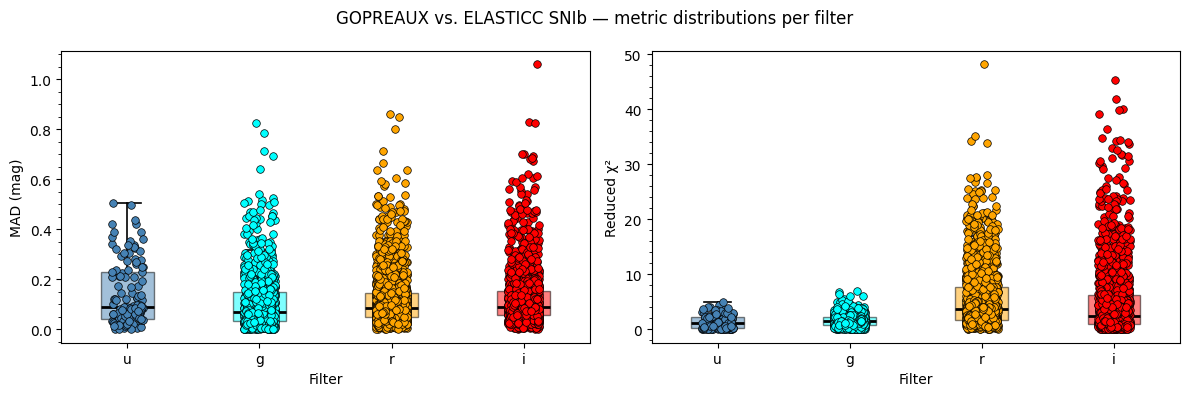

In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from caat.utils import colors as FILT_COLORS

results = pd.DataFrame(rows)
summary = results.groupby("Filter")[["GOPREAUX_mad", "GOPREAUX_chi2"]].median()
print("Median MAD and reduced chi^2 per filter (lower is better):\n")
print(summary.to_string())

FILT_ORDER = [f for f in ["u", "g", "r", "i", "z", "Y"] if f in results["Filter"].unique()]
filt_positions = {f: i for i, f in enumerate(FILT_ORDER)}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric, label in zip(
    axes,
    ["GOPREAUX_mad", "GOPREAUX_chi2"],
    ["MAD (mag)", "Reduced χ²"],
):
    box_data = [results.loc[results["Filter"] == f, metric].dropna().values for f in FILT_ORDER]
    bp = ax.boxplot(
        box_data,
        positions=range(len(FILT_ORDER)),
        widths=0.4,
        patch_artist=True,
        medianprops=dict(color="k", linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker=""),
    )
    for patch, filt in zip(bp["boxes"], FILT_ORDER):
        patch.set_facecolor(FILT_COLORS.get(filt, "steelblue"))
        patch.set_alpha(0.5)

    # Overlay individual SN points with jitter
    rng = np.random.default_rng(0)
    for i, filt in enumerate(FILT_ORDER):
        vals = results.loc[results["Filter"] == filt, metric].dropna().values
        jitter = rng.uniform(-0.12, 0.12, size=len(vals))
        ax.scatter(
            i + jitter, vals,
            color=FILT_COLORS.get(filt, "steelblue"),
            edgecolors="k", linewidths=0.5,
            s=30, zorder=3,
        )

    ax.set_xticks(range(len(FILT_ORDER)))
    ax.set_xticklabels(FILT_ORDER)
    ax.set_xlabel("Filter")
    ax.set_ylabel(label)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

fig.suptitle("GOPREAUX vs. ELASTICC SNIb — metric distributions per filter")
plt.tight_layout()
plt.show()